# Randomized Kaczmarz & Ensemble Kalman Inversion

This notebook demonstrates two geophysically-inspired unfolding methods:

1. **Randomized Kaczmarz** — a stochastic row-projection method (Strohmer & Vershynin, 2009)
2. **Ensemble Kalman Inversion (EKI)** — Bayesian posterior approximation without MCMC (Iglesias et al., 2013)

Uses the ISO Cf-252 reference spectrum from the IAEA Compendium.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bssunfold import Detector

%matplotlib inline

## Setup

Load the ISO Cf-252 reference spectrum from the IAEA Compendium and generate detector readings.

In [2]:
det = Detector()
E = det.E_MeV

reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV', 'ISO_ref_Cf252']])

# Interpolate reference spectrum onto detector energy grid for comparison
ref_dict = {"E_MeV": reference_spectrum['E_MeV'].values, "Phi": reference_spectrum['ISO_ref_Cf252'].values}
interp_df = det.discretize_spectra(ref_dict)
true_spectrum = interp_df["Phi"].values

print(f"Detectors: {det.n_detectors}, Energy bins: {det.n_energy_bins}")
print(f"Reference spectrum: ISO_ref_Cf252 (Cf-252)")

Detectors: 10, Energy bins: 60
Reference spectrum: ISO_ref_Cf252 (Cf-252)


## Unfolding with Randomized Kaczmarz

The randomized Kaczmarz selects rows probabilistically with probability proportional to the squared row norm. This gives faster convergence than the deterministic cyclic variant for ill-conditioned systems.

In [3]:
result_rk = det.unfold_randomized_kaczmarz(
    readings, max_iterations=500, random_state=42, save_result=False,
)

print(f"Method: {result_rk['method']}")
print(f"Residual norm: {result_rk['residual_norm']:.6f}")

Method: Randomized Kaczmarz
Residual norm: 0.009622


## Unfolding with Ensemble Kalman Inversion

EKI propagates an ensemble of particles through the forward model and updates them via the Kalman gain equation. The regularized variant adds `alpha * I` to the covariance matrices for numerical stability.

In [4]:
result_eki = det.unfold_eki(
    readings, n_ensemble=50, n_iterations=30,
    regularization=1e-4, random_state=42, save_result=False,
)

print(f"Method: {result_eki['method']}")
print(f"Residual norm: {result_eki['residual_norm']:.6f}")

Method: EKI
Residual norm: 0.144670


## Comparison with established methods

In [5]:
result_mlem = det.unfold_mlem(readings, max_iterations=500, save_result=False)
result_lw = det.unfold_landweber(readings, max_iterations=500, save_result=False)
result_cgls = det.unfold_cgls(readings, max_iterations=100, save_result=False)

from bssunfold.utils.comparison import compare_spectra

methods = {
    "Randomized Kaczmarz": result_rk,
    "EKI": result_eki,
    "MLEM": result_mlem,
    "Landweber": result_lw,
    "CGLS": result_cgls,
}

for name, res in methods.items():
    metrics = compare_spectra(true_spectrum, res["spectrum"], energy=E)
    print(f"{name:25s}  cos_sim={metrics['cosine_similarity']:.4f}  "
          f"R2={metrics['r2_score']:.4f}  residual={res['residual_norm']:.6f}")

Randomized Kaczmarz        cos_sim=0.9816  R2=0.9558  residual=0.009622
EKI                        cos_sim=0.7225  R2=0.1234  residual=0.144670
MLEM                       cos_sim=0.7065  R2=0.3463  residual=0.200153
Landweber                  cos_sim=0.9862  R2=0.9683  residual=0.003541
CGLS                       cos_sim=0.9962  R2=0.9914  residual=0.006473


## Spectral comparison plot

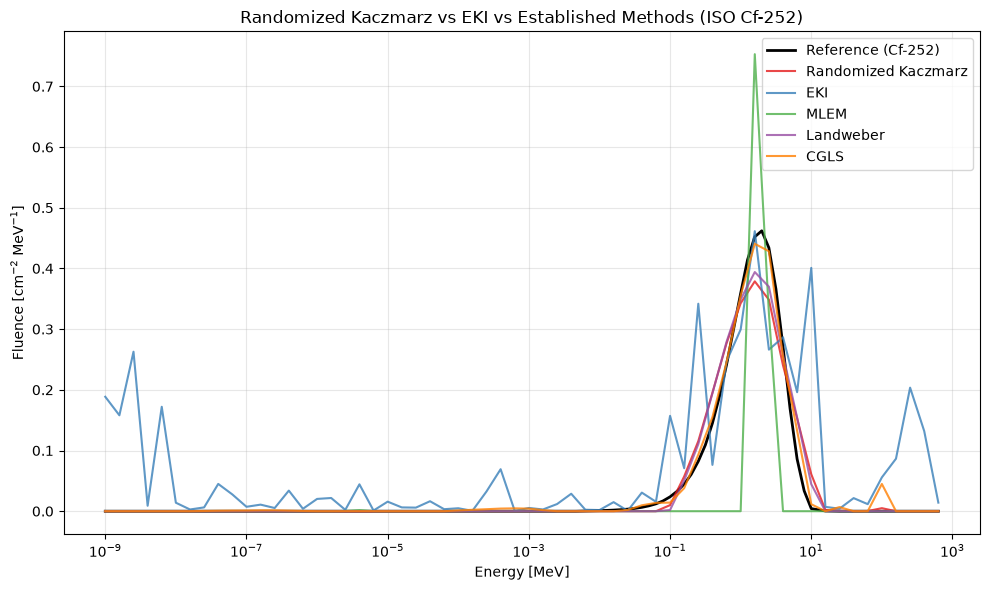

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot reference on original CSV energy grid
ax.plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], "k-", lw=2, label="Reference (Cf-252)")
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
for (name, res), c in zip(methods.items(), colors):
    ax.plot(E, res["spectrum"], color=c, alpha=0.8, label=name)

ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Fluence [cm$^{-2}$ MeV$^{-1}$]")
ax.set_title("Randomized Kaczmarz vs EKI vs Established Methods (ISO Cf-252)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()